In [1]:
import selfTracking

In [68]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stat
import matplotlib.pyplot as plt
import os

I have already recorded some data about myself. Here I intend to utilise this package in order to answer such questions as:
- at which hours am I most productive?
- at which hours do I usually rest?
- how often should I take breaks?

## Gathering the data

First, one needs to load the raw data from the analyzer. In folder "./data/", multiple logs from many days are saved:

In [90]:
os.listdir("./data/")

['2022-10-19.txt',
 '2022-10-20.txt',
 '2022-10-21.txt',
 '2022-10-22.txt',
 '2022-10-23.txt',
 '2022-10-24.txt',
 '2022-10-25.txt',
 '2022-10-26.txt',
 '2022-10-27.txt',
 '2022-10-28.txt',
 '2022-10-29.txt',
 '2022-10-30.txt',
 '2022-10-31.txt',
 '2022-11-1.txt',
 '2022-11-2.txt',
 '2022-11-3.txt',
 'flag_data.csv',
 'flag_rules.csv',
 'hand_flagged_windows.csv',
 'time_series.csv']

The analyzer will read all said logs and concatenate them into a single dataframe:

In [104]:
analyzer = selfTracking.Analyzer(data_directory="./data/")
analyzer.load_raw_data()
analyzer.raw_data.head()

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed
0,0,2022,10,18,22,38,35,1,1.666126e+09,40245.224468,False,Domyślny ekran blokady systemu Windows,,
1,1,2022,10,19,9,49,20,2,1.666166e+09,4.585373,True,Domyślny ekran blokady systemu Windows,,space
2,2,2022,10,19,9,49,24,2,1.666166e+09,2.936318,True,,,
3,3,2022,10,19,9,49,27,2,1.666166e+09,5.210016,True,C:\Windows\system32\cmd.exe,,
4,4,2022,10,19,9,49,33,2,1.666166e+09,2.388092,True,D-separation - Google Chrome,,


at this point, however, no block contains any flags (the 'flag' column does not yet exist). However, I have already previously set up the flag files and so the analyzer can set up these flags rather quickly:

In [105]:
analyzer.update_flag_file()
analyzer.assign_flags()
analyzer.raw_data[analyzer.raw_data.flag != ""].head()

C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:80: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  flag_data = pd.read_csv(self.flag_data, encoding="utf-8", sep=self.flag_separator, dtype='str', index_col=None)
C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:83: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  hand_flagged_windows = pd.read_csv(self.hand_flagged_windows, encoding="utf-8", sep=self.flag_separator, dtype='str', index_col=None)
C:\Users\PC\anaconda3\lib\site-packages\selfTracking\Analyzer.py:87: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char lon

,index,year,month,day,hour,min,sec,weekday,secStart,secSpent,active,Window,textWritten,keysPressed,flag
187,187,2022,10,19,22,39,31,2,1.666212e+09,3.398877,True,PyCharm User Agreement,,,coding
190,190,2022,10,19,22,39,45,2,1.666212e+09,29.008390,True,Welcome to PyCharm,,,coding
202,202,2022,10,19,22,49,20,2,1.666213e+09,25.961823,True,python - How do I use Anaconda packages in PyC...,,,coding
206,206,2022,10,19,22,50,8,2,1.666213e+09,1.315944,True,python - How do I use Anaconda packages in PyC...,t,right ctrlt,coding
220,220,2022,10,19,22,52,55,2,1.666213e+09,1.895729,True,Configure a Conda virtual environment | PyChar...,,,coding


As can be seen, some block have already been assigned to their respective flags.

Now, to make this into a time-series data with interesting statistics, let's first define the statistics that interes us:

In [106]:
def resting(row):
    return 1 if row.flag == 'rest' or row.active == False else 0

def words_per_second(row):
    return (len(row.textWritten.split(" ")) - 1) / row.secSpent if row.flag != 'rest' else 0


def letters_per_second(row):
    return (len(row.textWritten)) / row.secSpent if row.flag != 'rest' else 0

def is_block(row):
    return 1 if row.flag else 1

all_statistics = [resting, words_per_second, letters_per_second, is_block]

and now generate the time series data with said statistics:

In [107]:
data = analyzer.make_time_series( all_statistics )
data.head()

,index,resting,words_per_second,letters_per_second,is_block
1666125515,0.0,0.998843,0.0,0.0,0.998843
1666125575,0.0,1.000000,0.0,0.0,1.000000
1666125635,0.0,1.000000,0.0,0.0,1.000000
1666125695,0.0,1.000000,0.0,0.0,1.000000
1666125755,0.0,1.000000,0.0,0.0,1.000000


## Average productivity vs hour

In order to find out at which hours I am most productive, let's plot the quantity of my work versus the hour.

first need to get a column that represents time, but can also be interpreted by pandas

In [125]:
def get_time(row):
    sec = row.name
    time = dt.datetime.fromtimestamp( sec ).time()
    return time.hour*100 + time.minute*100/60

In [126]:
data["hour"] = data.apply( get_time  , axis = 1)

now to get a data of 'mean' for each day

In [127]:
aaa = data.groupby( "hour" ).mean()

In [128]:
aaa

,index,resting,words_per_second,letters_per_second,is_block
hour,,,,,
0.000000,2371.244473,0.437500,0.002087,0.010420,0.8125
1.666667,2371.912331,0.428934,0.000004,0.000004,0.8125
3.333333,2372.277674,0.500000,0.000004,0.000004,0.8125
5.000000,2372.500564,0.425153,0.000004,0.000004,0.8125
6.666667,2372.652828,0.375000,0.000004,0.000004,0.8125
...,...,...,...,...,...
2391.666667,2369.928311,0.437500,0.000004,0.000004,0.8125
2393.333333,2369.937500,0.437500,0.000004,0.000004,0.8125
2395.000000,2370.104662,0.413078,0.001045,0.001045,0.8125


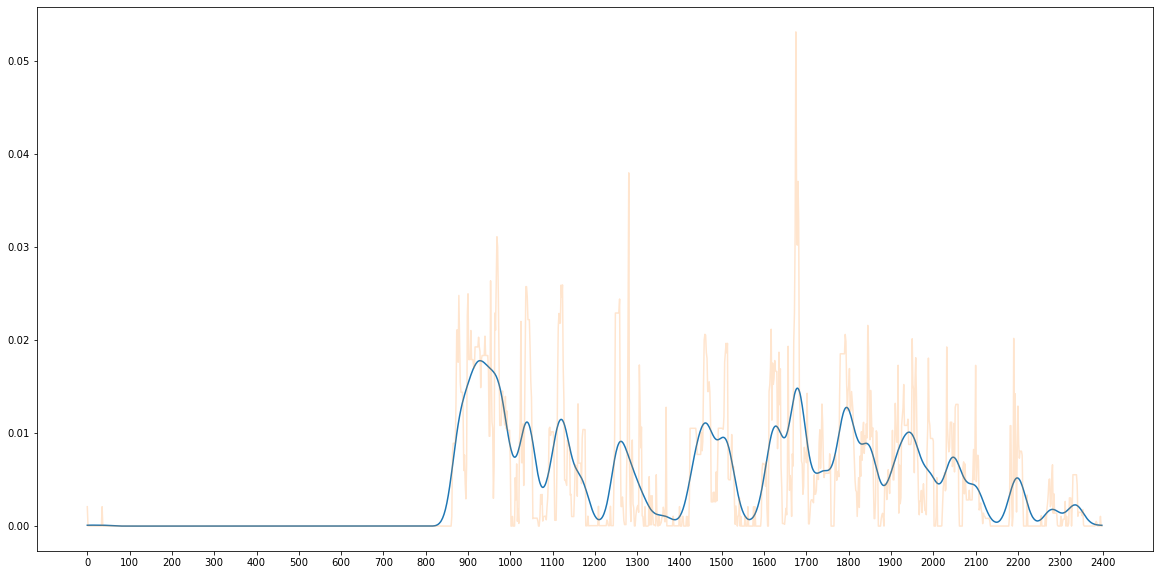

In [144]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1)*0.1 for i in range(-30,30)]
#smoothed_lps = np.convolve( aaa.letters_per_second*10 , kernel , "same" )
smoothed_wpd = np.convolve( aaa.words_per_second , kernel , "same" )

#ax.plot( aaa.index , smoothed_lps )
ax.plot( aaa.index , smoothed_wpd )
#ax.plot( aaa.index ,  aaa.letters_per_second*1 )
ax.plot( aaa.index , aaa.words_per_second , alpha = 0.2 )
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] );


## Average "is resting" vs hour

In other words: during which time of the dat do I most often rest? Unfortunately, I either assume that I'm not resting while not using the computer or assume I am resting. However, considering I mostly work on my computer I will assume resting.

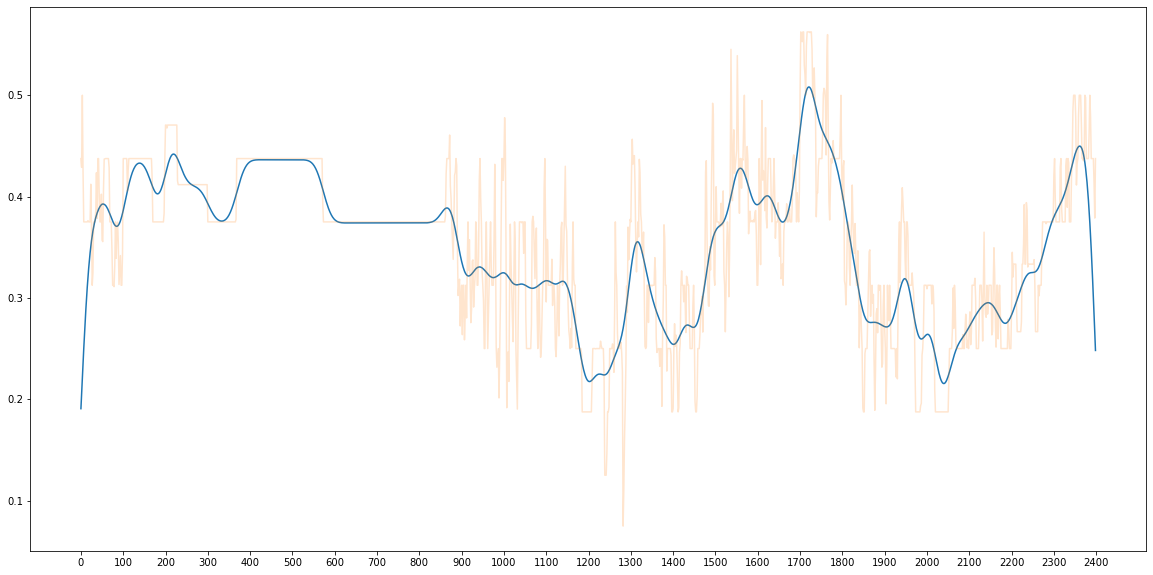

In [145]:
fig, ax = plt.subplots()


kernel = [ stat.norm.pdf(i*0.1)*0.1 for i in range(-30,30)]
smoothed_resting = np.convolve( aaa.resting , kernel , "same" )

ax.plot( aaa.index , smoothed_resting)
ax.plot( aaa.index , aaa.resting , alpha = 0.2 )
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] );


## Productivity vs time from last break plot

In [131]:
data.loc[:,"last_rest"] = 1 - data.loc[:,"resting"]*data.loc[:,"is_block"]

In [132]:
last_idx = 1666125515
for idx,row in data.iterrows():
    if row.resting != 1 and row.is_block:
        row.loc["last_rest"] = data.loc[last_idx,"last_rest"] + (idx - last_idx)/60
    last_idx = idx

In [133]:
data.head()

,index,resting,words_per_second,letters_per_second,is_block,hour,last_rest
1666125515,0.0,0.998843,0.0,0.0,0.998843,2263.333333,0.002312
1666125575,0.0,1.000000,0.0,0.0,1.000000,2265.000000,0.000000
1666125635,0.0,1.000000,0.0,0.0,1.000000,2266.666667,0.000000
1666125695,0.0,1.000000,0.0,0.0,1.000000,2268.333333,0.000000
1666125755,0.0,1.000000,0.0,0.0,1.000000,2270.000000,0.000000


In [134]:
rest_data = data[data.last_rest < 60*5].groupby("last_rest").mean()

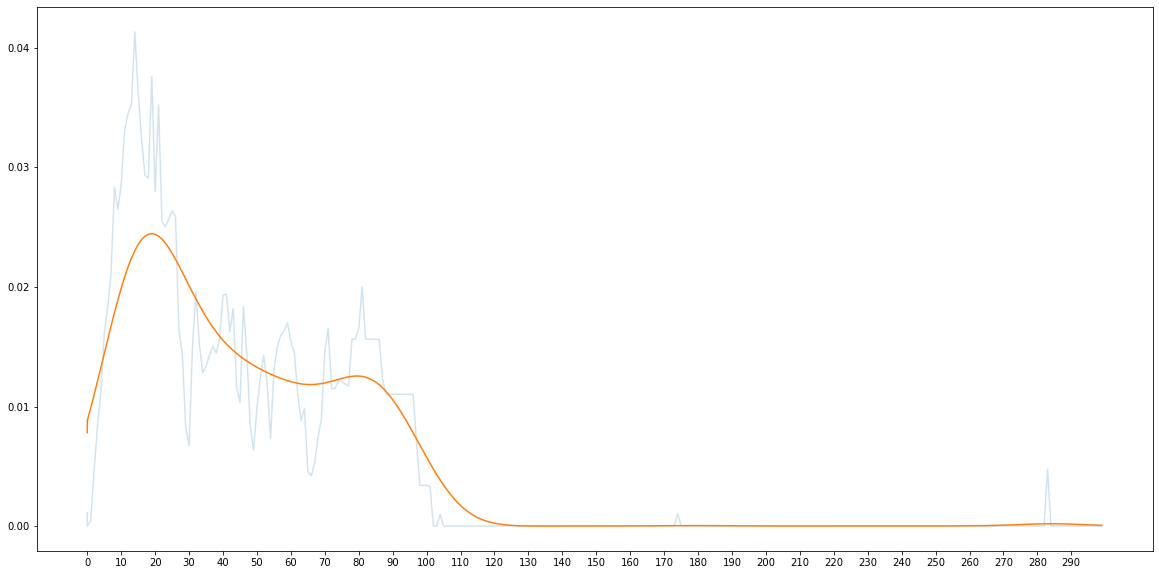

In [146]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1)*0.1 for i in range(-30,30)]
smoothed_words = np.convolve( rest_data.words_per_second , kernel , "same" )

fig.set_size_inches(20,10)
ax.plot( rest_data.index , rest_data.words_per_second, alpha = 0.2)
ax.plot( rest_data.index , smoothed_words )

ax.set_xticks( [ i*10 for i in range(30) ] );


It would seem that I don't work for longer than 100 minutes at a time. Moreover I appear to be about 3 times more productive within the first 30 minutes of my work than during the later 70 minutes. I should probably consider taking breaks more often.